# Corrected record: every paper number checked, as a demo notebook

This notebook is the evaluation script **`eval.py`** from the artifact *"Corrected record: every paper number checked"* (iteration 5, evaluation 4). The artifact belongs to a research project on **gold-free faithfulness metrics for NL→FOL autoformalization**.

The iteration-4 paper got a blocking review (score 3, 11 critiques), mostly about numbers in the text that did not match the result files. `eval.py` does not trust any number that someone typed by hand. For every numeric claim it:

1. takes the **claim literal** as written in the hypothesis (§0.2–0.3) or in the review (for example `"0.614"`, `"[0.493, 0.736]"`, `"+0.099"`, `"44.9%"`);
2. reads the **file value** through a small *locator* (JSON key, CSV row/column, regex, JSONL count, cost-ledger sum, or an arithmetic expression over these);
3. compares the two with a precision rule: MATCH iff |claim − file| ≤ 0.5·10⁻ᵈ at the claim's own number of decimals. CI bounds are checked separately, and signs must agree;
4. looks the same quantity up in the **paper draft** and marks paper-vs-file MATCH or MISMATCH;
5. maps every decimal number named in the 11 review critiques onto a checked row (`MAPPED` or `UNMAPPED`);
6. runs a **mutation test** of the checker: perturbed claims must be caught (a verifier that cannot fail proves nothing).

The full pipeline also builds `record_final.md` (17 corrected sections), lints, a claims ledger, the iteration-5 skeleton, figures and an independent audit. Those steps need the whole multi-GB run tree of 59 source files, so this demo runs the **core checker path** on a curated subset:

* **90 claims + 10 transcription rows**, chosen to include all 15 paper-vs-file mismatches, all review-critique claims, the 20 mutation-test claims and every locator type;
* a **pruned virtual file system** (`data["files"]`) that holds exactly the parts of each source file the locators read. The original locator code runs unchanged on top of it;
* the statuses the full run produced for these rows (`data["expected"]`), so the demo can check that it reproduces them.

The code cells are copied verbatim from `eval.py`, `src/io_locators.py`, `src/checker.py` and `src/mutation.py`. Every change is marked with a `# DEMO:` comment.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'PyYAML==6.0.3')

## Imports

The first block is the original import block of `eval.py`. The second collects the imports of the `src/` modules inlined below (`io_locators`, `checker`, `mutation`), plus `pandas`/`matplotlib` for the final summary.

In [2]:
from __future__ import annotations

import csv
import json
import re
import subprocess
import sys
import time
from collections import Counter
from pathlib import Path

from loguru import logger

# imports of the inlined src/ modules
import copy
import hashlib
import io
import math
from types import SimpleNamespace
from typing import Any

# notebook-only: results table and plots
import pandas as pd
import matplotlib.pyplot as plt

## Data loading

The mini data is loaded from GitHub, with a local fallback. It holds the claim specs, the pruned source files, the paper draft, the review critiques and the expected statuses.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_StxQVNnY7aQW/round-5/evaluation-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print(f"claims: {len(data['claims'])}, transcriptions: {len(data['transcriptions'])}, virtual files: {len(data['files'])}")

Mini demo data for the corrected-record checker (iter 5, eval 4): 90 hypothesis/review claim specs + 10 transcription rows, a pruned virtual file system holding exactly the source-file parts their locators read, the iter-4 paper draft, the 11 review critiques, and the statuses the full run produced for these rows.
claims: 90, transcriptions: 10, virtual files: 32


## Configuration

The original checks **244 claims + 258 transcription rows** in about 30 s, CPU only, with no LLM calls and $0 spent. The mini data holds 90 claims and 10 transcription rows. The two numbers below set how many of them are checked. The mutation test always uses its 20 fixed claim IDs, which are all in the mini data.

In [5]:
N_CLAIMS = 90       # claims to check (max 90 in mini data; original full run: 244)
N_TRANSCRIBED = 10   # transcription rows to check (max 10 in mini data; original full run: 258)

## Locators: reading one value from a source file (`src/io_locators.py`)

Each number is pulled through a **locator dict**, such as `{"t": "json", "f": <file>, "k": "a.b.c"}` or `{"t": "csv", "f": ..., "where": {...}, "col": ...}`.

* `_walk_key` resolves dotted JSON keys whose parts may themselves contain dots or spaces, taking the longest matching key at each level.
* `csv_cell` raises `Ambiguous` when several rows match with different values.
* `expr` combines sub-locators arithmetically, for example sign-flipping a delta.

Every file read is hashed into `HASHES`. The one change: `_read_text` reads from `data["files"]`, the pruned copies, instead of from the server's absolute paths.

In [6]:
"""Loaders that read one value from a source file and return (value, locator_string).

Every number in the corrected record is pulled through one of these functions. A locator
is a small dict (see `resolve`) so it can be stored in claims_spec.yaml and replayed.
Paths are absolute and read-only; every file read is hashed into a registry.
"""

RUN = "run"  # original: the absolute 3_invention_loop directory of the source run; here the key root of data["files"]
I3 = f"{RUN}/iter_3/gen_art"
I4 = f"{RUN}/iter_4/gen_art"
PAPER = f"{RUN}/iter_4/gen_report_text/gen_report_text/paper_draft.md"
REVIEW = f"{RUN}/iter_4/review_report/review_report/.terminal_claude_agent_struct_out.json"

HASHES: dict[str, str] = {}
_JSON_CACHE: dict[str, Any] = {}
_TEXT_CACHE: dict[str, str] = {}


class NotFound(Exception):
    """The file or the key does not exist."""


class Ambiguous(Exception):
    """More than one candidate cell matched."""


def _read_text(path: str) -> str:
    if path not in _TEXT_CACHE:
        # DEMO: read from the pruned virtual file system in mini_demo_data.json instead of the disk
        if path not in data["files"]:
            raise NotFound(f"source missing: {path}")
        b = data["files"][path].encode("utf-8")
        HASHES[path] = hashlib.sha256(b).hexdigest()
        _TEXT_CACHE[path] = b.decode("utf-8", errors="replace")
    return _TEXT_CACHE[path]


def _load_json(path: str) -> Any:
    if path not in _JSON_CACHE:
        _JSON_CACHE[path] = json.loads(_read_text(path))
    return _JSON_CACHE[path]


def _walk_key(obj: Any, key: str) -> Any:
    """Resolve a dotted key where individual keys may themselves contain dots/spaces.

    At each level the longest prefix of the remaining path that is a key is taken.
    List indices are written as [i] directly after a key or as a bare integer part.
    """
    rest = key
    cur = obj
    while rest:
        m = re.match(r"^\[(\d+)\]\.?", rest)
        if m and isinstance(cur, list):
            cur = cur[int(m.group(1))]
            rest = rest[m.end():]
            continue
        if isinstance(cur, list):
            m = re.match(r"^(\d+)\.?", rest)
            if not m:
                raise NotFound(f"list index expected at '{rest}'")
            cur = cur[int(m.group(1))]
            rest = rest[m.end():]
            continue
        if not isinstance(cur, dict):
            raise NotFound(f"cannot descend into {type(cur).__name__} at '{rest}'")
        hit = None
        for k in sorted(cur.keys(), key=len, reverse=True):
            if rest == k or rest.startswith(k + ".") or rest.startswith(k + "["):
                hit = k
                break
        if hit is None:
            raise NotFound(f"key not found at '{rest[:60]}'")
        cur = cur[hit]
        rest = rest[len(hit):]
        if rest.startswith("."):
            rest = rest[1:]
    return cur


def json_key(path: str, dotted_key: str) -> tuple[Any, str]:
    return _walk_key(_load_json(path), dotted_key), f"{path} :: {dotted_key}"


def _csv_rows(path: str) -> list[dict[str, str]]:
    text = _read_text(path)
    lines = [ln for ln in text.splitlines() if not ln.startswith("# source") and not ln.startswith("#")]
    return list(csv.DictReader(io.StringIO("\n".join(lines))))


def csv_cell(path: str, row_filter: dict[str, str], col: str) -> tuple[Any, str]:
    rows = [r for r in _csv_rows(path) if all(str(r.get(k, "")) == str(v) for k, v in row_filter.items())]
    if not rows:
        raise NotFound(f"no csv row {row_filter} in {path}")
    vals = {r.get(col) for r in rows}
    if len(vals) > 1:
        raise Ambiguous(f"{len(rows)} rows with differing '{col}' for {row_filter}")
    if col not in rows[0]:
        raise NotFound(f"column {col} missing in {path}")
    filt = ", ".join(f"{k}={v}" for k, v in row_filter.items())
    return rows[0][col], f"{path} :: row[{filt}] col[{col}]"


def md_table_cell(path: str, table_heading: str, row_regex: str, col_index: int) -> tuple[Any, str]:
    """Fallback reader for markdown tables (used only when no machine source exists)."""
    text = _read_text(path)
    start = text.find(table_heading)
    if start < 0:
        raise NotFound(f"heading '{table_heading}' not in {path}")
    nxt = re.search(r"\n#{2,3} ", text[start + len(table_heading):])
    block = text[start: start + len(table_heading) + (nxt.start() if nxt else len(text))]
    rows = [ln for ln in block.splitlines() if ln.startswith("|") and re.search(row_regex, ln)]
    if not rows:
        raise NotFound(f"row /{row_regex}/ not in table '{table_heading}'")
    if len(rows) > 1:
        raise Ambiguous(f"{len(rows)} rows match /{row_regex}/")
    cells = [c.strip() for c in rows[0].strip().strip("|").split("|")]
    return cells[col_index], f"{path} :: table '{table_heading}' row /{row_regex}/ col {col_index}"


def regex(path: str, pattern: str, group: int = 1) -> tuple[Any, str]:
    text = _read_text(path)
    ms = list(re.finditer(pattern, text, flags=re.M))
    if not ms:
        raise NotFound(f"/{pattern}/ not in {path}")
    vals = {m.group(group) for m in ms}
    if len(vals) > 1:
        raise Ambiguous(f"/{pattern}/ matched {len(ms)} differing values")
    return ms[0].group(group), f"{path} :: regex /{pattern}/ group {group}"


def jsonl_count(path: str, where: dict[str, Any]) -> tuple[int, str]:
    text = _read_text(path)
    n = 0
    for ln in text.splitlines():
        if not ln.strip():
            continue
        r = json.loads(ln)
        if all(r.get(k) == v for k, v in where.items()):
            n += 1
    return n, f"{path} :: count rows where {where}"


def ledger_sum(path: str, field: str = "cost_usd") -> tuple[float, str]:
    text = _read_text(path)
    s = 0.0
    for ln in text.splitlines():
        if ln.strip():
            try:
                s += float(json.loads(ln).get(field) or 0.0)
            except (json.JSONDecodeError, TypeError, ValueError):
                continue
    return s, f"{path} :: sum({field})"


def to_float(v: Any) -> float:
    if isinstance(v, bool):
        return float(v)
    if isinstance(v, (int, float)):
        return float(v)
    s = str(v).strip().replace("−", "-").replace(",", "").replace("$", "")
    m = re.search(r"-?\d+(?:\.\d+)?(?:e-?\d+)?", s)
    if not m:
        raise ValueError(f"no number in {v!r}")
    return float(m.group(0))


def resolve(loc: dict[str, Any]) -> tuple[Any, str]:
    """Resolve a locator dict to (value, locator_string)."""
    t = loc["t"]
    if t == "json":
        v, s = json_key(loc["f"], loc["k"])
    elif t == "csv":
        v, s = csv_cell(loc["f"], loc["where"], loc["col"])
    elif t == "md":
        v, s = md_table_cell(loc["f"], loc["h"], loc["row"], loc["col"])
    elif t == "regex":
        v, s = regex(loc["f"], loc["pat"], loc.get("g", 1))
    elif t == "jsonl_count":
        v, s = jsonl_count(loc["f"], loc["where"])
    elif t == "ledger":
        v, s = ledger_sum(loc["f"], loc.get("field", "cost_usd"))
    elif t == "expr":
        env = {}
        parts = []
        for name, sub in loc["args"].items():
            val, sloc = resolve(sub)
            env[name] = to_float(val)
            parts.append(f"{name}={sloc}")
        v = eval(loc["expr"], {"__builtins__": {}}, env)  # noqa: S307 - arithmetic on file values only
        s = f"expr[{loc['expr']}] with " + " ; ".join(parts)
    elif t == "const":
        v, s = loc["v"], f"CONTEXT (no file value): {loc.get('why', '')}"
    else:
        raise ValueError(f"unknown locator type {t}")
    if "idx" in loc:
        v = v[loc["idx"]]
        s += f" [{loc['idx']}]"
    return v, s


# DEMO: the original code imports this module as `L`; expose the same names under L
L = SimpleNamespace(RUN=RUN, I3=I3, I4=I4, PAPER=PAPER, REVIEW=REVIEW, HASHES=HASHES, NotFound=NotFound, Ambiguous=Ambiguous,
                    _read_text=_read_text, _load_json=_load_json, _csv_rows=_csv_rows, to_float=to_float, resolve=resolve)
print(f"virtual files available: {len(data['files'])}")

virtual files available: 32


## The claim checker (`src/checker.py`)

`parse_literal` turns a claim literal into (value, tolerance), and the precision comes from the literal itself: `"0.614"` → ±0.0005, `"44.9%"` → 0.449 ± 0.0005, `"$4.33"` → ±0.005.

`check_claim` resolves the locator, compares the value and the CI (each bound at its own precision), and then looks for the same number in the paper. It uses the paper section named by `ps`. If the claim has a `pp` regex, it captures the *paper's own* number, which can differ from the claim, and compares that number with the file.

Statuses: `MATCH`, `MISMATCH`, `NOT_FOUND`, `AMBIGUOUS`, or `TRANSCRIBED` for rows that have no claim literal.

In [7]:
"""Claim checker: pull each claim's value from its source file and compare.

Precision rule: MATCH iff |claim - source| <= 0.5 * 10^-d (d = decimals of the claim literal;
percentages are compared as fractions, so '44.9%' has d = 3). A CI matches only if both bounds
match, each at its own precision. Signs must agree. Statuses: MATCH, MISMATCH, NOT_FOUND,
AMBIGUOUS. String claims (verdict labels) must equal the source string exactly.
"""

NUM_RE = r"[+\-−]?\$?\d[\d,]*(?:\.\d+)?(?:e[+\-−]?\d+)?%?"


def norm(s: str) -> str:
    return s.replace("−", "-").replace("−", "-").strip()


def is_numeric_literal(s: str) -> bool:
    return bool(re.fullmatch(r"[+\-]?\$?\d[\d,]*(?:\.\d+)?(?:e[+\-]?\d+)?%?", norm(s)))


def parse_literal(s: str) -> tuple[float, float, dict]:
    """Return (value_as_fraction_or_number, tolerance, format_info)."""
    t = norm(s)
    info = {"sign": t.startswith("+"), "pct": t.endswith("%"), "usd": "$" in t, "sci": "e" in t.lower()}
    core = t.replace("$", "").replace(",", "").rstrip("%").lstrip("+")
    if info["sci"]:
        mant, exp = core.lower().split("e")
        dec = len(mant.split(".")[1]) if "." in mant else 0
        val = float(core)
        tol = 0.5 * 10 ** (-dec) * 10 ** int(exp)
        info["dec"], info["exp"] = dec, int(exp)
    else:
        dec = len(core.split(".")[1]) if "." in core else 0
        val = float(core)
        tol = 0.5 * 10 ** (-dec)
        info["dec"] = dec
    if info["pct"]:
        val /= 100.0
        tol /= 100.0
    info["thousands"] = "," in t
    return val, tol * (1 + 1e-9) + 1e-12, info


def parse_ci(s: str) -> list[str]:
    parts = [p.strip() for p in norm(s).strip("[]").split(",")]
    if len(parts) != 2:
        raise ValueError(f"bad CI literal {s}")
    return parts


def fmt_like(v: float, claim_literal: str) -> str:
    """Format a file value at the claim literal's precision/style (display only)."""
    _, _, info = parse_literal(claim_literal)
    x = v * 100.0 if info["pct"] else v
    if info.get("sci"):
        body = f"{x / 10 ** info['exp']:.{info['dec']}f}e{info['exp']}"
    elif info["thousands"]:
        body = f"{x:,.{info['dec']}f}"
    else:
        body = f"{x:.{info['dec']}f}"
    if body.startswith("-"):
        body = "−" + body[1:]
    elif info["sign"] and x > 0:
        body = "+" + body
    if info["usd"]:
        body = ("−$" + body[1:]) if body.startswith("−") else "$" + body
    return body + ("%" if info["pct"] else "")


def fmt_ci_like(ci: list[float], claim_ci: str) -> str:
    lo_l, hi_l = parse_ci(claim_ci)
    return f"[{fmt_like(ci[0], lo_l)}, {fmt_like(ci[1], hi_l)}]"


def num_match(claim_literal: str, source: float) -> bool:
    val, tol, _ = parse_literal(claim_literal)
    if val != 0 and source != 0 and math.copysign(1, val) != math.copysign(1, source) and abs(source) > tol:
        return False
    return abs(val - source) <= tol


def split_value_ci(v: Any) -> tuple[Any, list[float] | None]:
    """A source cell like '0.278 [0.239, 0.319]' carries its own CI."""
    if isinstance(v, str) and "[" in v:
        m = re.match(r"\s*([^\[]+)\[([^,]+),([^\]]+)\]", v)
        if m:
            return m.group(1).strip(), [L.to_float(m.group(2)), L.to_float(m.group(3))]
    return v, None


def _get_ci(ciloc: Any) -> tuple[list[float], str]:
    if isinstance(ciloc, list):
        (lo, s1), (hi, s2) = L.resolve(ciloc[0]), L.resolve(ciloc[1])
        return [L.to_float(lo), L.to_float(hi)], f"{s1} ; {s2}"
    v, s = L.resolve(ciloc)
    return [L.to_float(v[0]), L.to_float(v[1])], s


# ---------------------------------------------------------------- paper helpers
_PAPER_LINES: list[str] | None = None


def paper_lines() -> list[str]:
    global _PAPER_LINES
    if _PAPER_LINES is None:
        _PAPER_LINES = L._read_text(L.PAPER).splitlines()
    return _PAPER_LINES


def section_range(prefix: str | None) -> tuple[int, int]:
    """1-based inclusive line range of the paper section whose heading starts with prefix."""
    lines = paper_lines()
    if not prefix:
        return 1, len(lines)
    for i, ln in enumerate(lines):
        if ln.startswith(prefix):
            level = len(ln) - len(ln.lstrip("#"))
            for j in range(i + 1, len(lines)):
                m = re.match(r"^(#+) ", lines[j])
                if m and len(m.group(1)) <= level:
                    return i + 1, j
            return i + 1, len(lines)
    return 1, len(lines)


def headings() -> list[tuple[int, str]]:
    return [(i + 1, ln) for i, ln in enumerate(paper_lines()) if re.match(r"^#+ ", ln)]


def literal_variants(lit: str) -> list[str]:
    t = norm(lit)
    out = {t, t.lstrip("+"), t.replace("-", "−"), t.lstrip("+").replace("-", "−")}
    if t.endswith("%"):
        v = float(t.rstrip("%").replace(",", "")) / 100
        out.add(f"{v:.3f}".rstrip("0"))
    return sorted(out, key=len, reverse=True)


def grep_paper(lit: str, prefix: str | None) -> tuple[str | None, int | None]:
    lo, hi = section_range(prefix)
    lines = paper_lines()
    for var in literal_variants(lit):
        pat = r"(?<![\d.])" + re.escape(var) + r"(?![\d])"
        for i in range(lo - 1, hi):
            if re.search(pat, lines[i]):
                return var, i + 1
    return None, None


def paper_pattern(pp: Any, prefix: str | None) -> tuple[str | None, int | None]:
    pat, grp = (pp, 1) if isinstance(pp, str) else pp
    lo, hi = section_range(prefix)
    lines = paper_lines()
    for i in range(lo - 1, hi):
        m = re.search(pat, lines[i])
        if m:
            return m.group(grp), i + 1
    return None, None


# ---------------------------------------------------------------- main check
def check_claim(cl: dict) -> dict:
    row = {k: cl.get(k) for k in ("id", "sec", "text", "value", "ci", "role", "ps")}
    row.update(source_path="", locator="", source_value="", source_ci="", match_hyp_vs_file="", paper_value="",
               paper_line="", match_paper_vs_file="", note="", source_value_raw=None, source_ci_raw=None)
    try:
        v, s = L.resolve(cl["loc"])
        row["locator"] = s
        row["source_path"] = s.split(" :: ")[0] if " :: " in s else s
        v, inline_ci = split_value_ci(v)
        ci_src = None
        if cl.get("ciloc"):
            ci_src, cs = _get_ci(cl["ciloc"])
            row["locator"] += f" || CI: {cs}"
        elif inline_ci is not None:
            ci_src = inline_ci
        if cl["loc"]["t"] == "const":
            row["note"] = "CONTEXT: no file value; " + cl["loc"].get("why", "")
        if cl["value"] is None:  # transcription row: value read by code, no claim literal
            fv = L.to_float(v)
            row["source_value_raw"] = fv
            fmt = cl.get("fmt", "0.000")
            row["source_value"] = (re.sub(r"e([+-])0*(\d)", lambda m: "e" + ("−" if m.group(1) == "-" else "") + m.group(2), f"{fv:.2e}") if fmt == "0.00e0" else fmt_like(fv, fmt))
            ok = True
        elif is_numeric_literal(cl["value"]):
            fv = L.to_float(v)
            row["source_value_raw"] = fv
            row["source_value"] = fmt_like(fv, cl["value"])
            ok = num_match(cl["value"], fv)
        else:
            row["source_value"] = str(v)
            row["source_value_raw"] = str(v)
            ok = str(v) == cl["value"]
        if cl.get("ci") and cl["value"] is None:
            if ci_src is not None:
                row["source_ci_raw"] = ci_src
                row["source_ci"] = fmt_ci_like(ci_src, cl["ci"])
        elif cl.get("ci"):
            if ci_src is None:
                if cl["id"] == "t1_vs_s4":  # CI of S4-c, sign-flipped
                    raw, cs = L.resolve({"t": "json", "f": cl["loc"]["args"]["a"]["f"],
                                         "k": cl["loc"]["args"]["a"]["k"][: -len(".delta")] + ".ci"})
                    ci_src = [-L.to_float(raw[1]), -L.to_float(raw[0])]
                    row["locator"] += f" || CI (negated, bounds swapped): {cs}"
                else:
                    row["note"] += " CI not in source;"
            if ci_src is not None:
                row["source_ci_raw"] = ci_src
                row["source_ci"] = fmt_ci_like(ci_src, cl["ci"])
                lo_l, hi_l = parse_ci(cl["ci"])
                ok = ok and num_match(lo_l, ci_src[0]) and num_match(hi_l, ci_src[1])
        elif ci_src is not None:
            row["source_ci_raw"] = ci_src
            row["source_ci"] = f"[{ci_src[0]:.3f}, {ci_src[1]:.3f}]".replace("-", "−")
        row["match_hyp_vs_file"] = ("TRANSCRIBED" if cl["value"] is None else ("MATCH" if ok else "MISMATCH"))
    except L.NotFound as e:
        row["match_hyp_vs_file"] = "NOT_FOUND"
        row["note"] += str(e)[:200]
        return row
    except L.Ambiguous as e:
        row["match_hyp_vs_file"] = "AMBIGUOUS"
        row["note"] += str(e)[:200]
        return row
    # paper side
    if cl["value"] is None:
        row["match_paper_vs_file"] = "n/a"
        return row
    if cl.get("pp"):
        pv, line = paper_pattern(cl["pp"], cl.get("ps"))
        if pv is None:
            row["paper_value"], row["match_paper_vs_file"] = "", "NOT_IN_PAPER"
        else:
            row["paper_value"], row["paper_line"] = pv, line
            if pv.startswith("["):
                lo_l, hi_l = parse_ci(pv)
                okp = row["source_ci_raw"] is not None and num_match(lo_l, row["source_ci_raw"][0]) and num_match(hi_l, row["source_ci_raw"][1])
            elif is_numeric_literal(pv) and isinstance(row["source_value_raw"], float):
                okp = num_match(pv, row["source_value_raw"])
            else:
                okp = pv == str(row["source_value_raw"])
            row["match_paper_vs_file"] = "MATCH" if okp else "MISMATCH"
    else:
        var, line = grep_paper(cl["value"], cl.get("ps")) if is_numeric_literal(cl["value"]) else (None, None)
        if var is None:
            row["match_paper_vs_file"] = "NOT_IN_PAPER"
        else:
            row["paper_value"], row["paper_line"] = var, line
            row["match_paper_vs_file"] = row["match_hyp_vs_file"]
    return row


def check_all(claims: list[dict]) -> list[dict]:
    return [check_claim(c) for c in claims]


def write_hashes(path: Path) -> None:
    lines = ["# source: sha256 of every file read by the locators (computed at read time)", "path,sha256"]
    lines += [f"{p},{h}" for p, h in sorted(L.HASHES.items())]
    path.write_text("\n".join(lines) + "\n")


# DEMO: the original code imports this module as `CK`
CK = SimpleNamespace(parse_literal=parse_literal, parse_ci=parse_ci, fmt_like=fmt_like, check_claim=check_claim,
                     check_all=check_all, write_hashes=write_hashes)

## The claim list (`src/claims_spec.py`, `src/transcribe.py`)

The claims are hand-curated. Each one holds the literal as written in the hypothesis or review, plus one locator; the values themselves are never typed. The original imports the lists `CLAIMS` (244) and `T` (258). Here they come from the mini data, cut to the configured size.

In [8]:
CLAIMS = data["claims"][:N_CLAIMS]                 # original: from src.claims_spec import CLAIMS
TRANSCRIBED = data["transcriptions"][:N_TRANSCRIBED]  # original: from src.transcribe import T as TRANSCRIBED
for c in CLAIMS[:3]:
    print(json.dumps({k: c[k] for k in ("id", "sec", "text", "value", "ci", "loc")}, ensure_ascii=False)[:300])

{"id": "t1_strat_c", "sec": "hyp §0.2 T1", "text": "c_score_align strat AUROC on E R_AB", "value": "0.741", "ci": null, "loc": {"t": "json", "f": "run/iter_3/gen_art/gen_art_experiment_6/results/analysis_T1.json", "k": "a_head_on.R_AB pooled.deltas.c_score_align - judge_cheap_disg [strat].auroc_a"}}
{"id": "t1_strat_j", "sec": "hyp §0.2 T1", "text": "flash-lite disguised strat AUROC on E R_AB", "value": "0.642", "ci": null, "loc": {"t": "json", "f": "run/iter_3/gen_art/gen_art_experiment_6/results/analysis_T1.json", "k": "a_head_on.R_AB pooled.deltas.c_score_align - judge_cheap_disg [strat].aur
{"id": "t1_delta", "sec": "hyp §0.2 T1", "text": "Δ c_score_align − flash-lite disguised, strat, R_AB", "value": "+0.099", "ci": "[0.049, 0.146]", "loc": {"t": "json", "f": "run/iter_3/gen_art/gen_art_experiment_6/results/analysis_T1.json", "k": "a_head_on.R_AB pooled.deltas.c_score_align - judge_ch


## `eval.py`: logging setup and output helpers

* `write_numbers` writes `numbers.csv`: one row per claim with the claim value, file value, locator, paper value, paper line and both statuses.
* `review_numbers` extracts every decimal or percentage literal from the 11 review critiques and marks it `MAPPED` if some checked row carries that value, or one of its CI bounds, at the literal's precision.

In [9]:
WS = Path(".").resolve()  # original: the script's own directory (Path(__file__)); sys.path insert for src/ not needed here
(WS / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(WS / "logs/run.log", rotation="30 MB", level="DEBUG")
(WS / "tables").mkdir(exist_ok=True)  # DEMO: exists in the original workspace
(WS / "audit").mkdir(exist_ok=True)   # DEMO: exists in the original workspace

NUM_COLS = ["claim_id", "section", "claim_text", "claim_value", "claim_ci", "source_path", "locator", "source_value",
            "source_ci", "match_hyp_vs_file", "paper_value", "paper_line", "match_paper_vs_file", "data_role", "note"]


def write_numbers(rows: list[dict], path: Path) -> None:
    with path.open("w", newline="") as f:
        f.write("# source: every row's value is read by src/io_locators.py from source_path at locator (never typed); "
                "claim_value is the hypothesis/review literal; statuses per src/checker.py precision rule\n")
        w = csv.writer(f)
        w.writerow(NUM_COLS)
        for r in rows:
            w.writerow([r["id"], r.get("sec"), r.get("text"), r.get("value") or "", r.get("ci") or "", r.get("source_path"),
                        r.get("locator"), r.get("source_value"), r.get("source_ci"), r.get("match_hyp_vs_file"),
                        r.get("paper_value"), r.get("paper_line"), r.get("match_paper_vs_file"), r.get("role"), r.get("note")])


def review_numbers(rows: list[dict]) -> list[dict]:
    """(ii) every number named in the 11 critiques -> covered by a numbers.csv row or UNMAPPED."""
    rv = json.loads(L._read_text(L.REVIEW))
    vals = []
    for r in rows:
        for key in ("source_value_raw",):
            v = r.get(key)
            if isinstance(v, float):
                vals.append((v, r["id"]))
        ci = r.get("source_ci_raw")
        if ci:
            vals += [(ci[0], r["id"]), (ci[1], r["id"])]
        pv = r.get("paper_value")
        if pv and str(pv).startswith("["):
            try:
                for b in CK.parse_ci(str(pv)):
                    vals.append((CK.parse_literal(b)[0], r["id"] + "(paper CI)"))
            except ValueError:
                pass
        if pv and re.fullmatch(r"[+\-−]?\$?\d[\d.,]*%?", str(pv)):
            try:
                vals.append((CK.parse_literal(str(pv))[0], r["id"] + "(paper)"))
            except ValueError:
                pass
    out = []
    for k, cr in enumerate(rv["critiques"], 1):
        text = cr["description"] + " " + cr["suggested_action"]
        for m in re.finditer(r"(?<![\w.])[+\-−]?\$?\d+(?:\.\d+)?%?(?![\w])", text):
            lit = m.group(0)
            pre = text[max(0, m.start() - 8): m.start()]
            if re.search(r"(§|§\d(?:\.\d)?[–-]|arXiv |\()$", pre) or re.fullmatch(r"\d{4}\.\d{5}", lit):
                continue  # section numbers and arXiv ids are not measurements
            if not re.search(r"\.\d|%", lit):
                continue  # integers (section numbers, counts) are not checked here
            try:
                val, tol, _ = CK.parse_literal(lit)
            except ValueError:
                continue
            hits = sorted({rid for v, rid in vals if abs(abs(v) - abs(val)) <= tol})
            out.append(dict(critique=k, literal=lit, context=text[max(0, m.start() - 50): m.end() + 30].replace("\n", " "),
                            covered_by=";".join(hits[:5]), status="MAPPED" if hits else "UNMAPPED"))
    return out

## Run the checker (the first part of `main()`)

This part exports the claim spec as YAML, checks every claim and transcription row, and counts the statuses in two directions:
* **hyp-vs-file**: is the hypothesis or review literal correct?
* **paper-vs-file**: does the paper say what the file says?

In [10]:
t0 = time.time()
# DEMO: the original asserts that no LLM/network client is imported; on Colab the runtime itself preloads `requests`
# assert "openai" not in sys.modules and "requests" not in sys.modules
import yaml
(WS / "claims_spec.yaml").write_text("# hand-curated claim list: literal as written in hypothesis §0.2-0.3 / review + one locator each (values are pulled by code)\n"
                                     + yaml.safe_dump({"claims": CLAIMS, "transcriptions": TRANSCRIBED}, allow_unicode=True, sort_keys=False, width=200))
logger.info(f"checking {len(CLAIMS)} claims + {len(TRANSCRIBED)} transcription rows")
rows = CK.check_all(CLAIMS) + CK.check_all(TRANSCRIBED)
cnt = Counter(r["match_hyp_vs_file"] for r in rows)
logger.info(f"hyp-vs-file: {dict(cnt)}; paper-vs-file: {dict(Counter(r['match_paper_vs_file'] for r in rows))}")
bad = [r for r in rows if r["match_hyp_vs_file"] in ("NOT_FOUND", "AMBIGUOUS")]
for r in bad:
    logger.warning(f"{r['id']}: {r['match_hyp_vs_file']} {r['note'][:160]}")

t_check = time.time() - t0

12:00:31|INFO   |checking 90 claims + 10 transcription rows


12:00:31|INFO   |hyp-vs-file: {'MATCH': 90, 'TRANSCRIBED': 10}; paper-vs-file: {'MATCH': 52, 'NOT_IN_PAPER': 23, 'MISMATCH': 15, 'n/a': 10}


## Write `numbers.csv`, `mismatches.csv` and the review-number map

In the full run the spend ledger, `record_final.md` and its 8 lints come first (`src/spend.py`, `src/sections.py`, `src/lints.py`). They need the full run tree, so they are skipped here. The table-writing steps that follow are kept as written; tables that depend on the skipped steps are left out.

In [11]:
# --- skipped in the demo (need the full run tree): spend ledger, record_final.md, lints ---
# from src.spend import run as spend_run; sp = spend_run(WS / "results")
# from src.sections import build; ctx = Ctx(rows); md, ids = build(ctx, sp); (WS / "record_final.md").write_text(md)
# fails = lint_all(md, numbers)
fails = []  # DEMO: no lints run here
ctx = SimpleNamespace(rows=rows)  # DEMO: Ctx(rows) only adds computed rows from the skipped steps; keep its .rows interface

write_numbers(ctx.rows, WS / "numbers.csv")
mism = [r for r in ctx.rows if r.get("match_hyp_vs_file") in ("MISMATCH", "NOT_FOUND", "AMBIGUOUS") or r.get("match_paper_vs_file") == "MISMATCH"]
write_numbers(mism, WS / "mismatches.csv")
rn = review_numbers(ctx.rows)
with (WS / "tables/review_numbers.csv").open("w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["critique", "literal", "status", "covered_by", "context"])
    w.writeheader()
    for r in rn:
        w.writerow(r)
logger.info(f"review critique numbers: {Counter(r['status'] for r in rn)}")
logger.info(f"numbers.csv: {len(ctx.rows)} rows; mismatches.csv: {len(mism)} rows")

12:00:31|INFO   |review critique numbers: Counter({'MAPPED': 146, 'UNMAPPED': 61})


12:00:31|INFO   |numbers.csv: 100 rows; mismatches.csv: 15 rows


## Checker mutation test (`src/mutation.py`)

A checker that always says MATCH would pass every claim, so the test makes 10 perturbed claims:
* 5 with the last digit changed,
* 3 with the CI bounds swapped,
* 2 with the sign flipped.

All 10 must come out **MISMATCH**, and 10 untouched claims must still be **MATCH**. The original runs this on the full `CLAIMS` list. Here it runs on all claims in the mini data, which contain the 20 IDs the test needs.

In [12]:
"""Mutation test of the checker: a verifier that cannot fail proves nothing.
Inject 10 perturbed claims (last digit changed, CI bounds swapped, sign flipped) -> all must be
MISMATCH; re-check 10 untouched claims -> all must be MATCH."""

def _bump_last_digit(lit: str) -> str:
    for i in range(len(lit) - 1, -1, -1):
        if lit[i].isdigit():
            d = int(lit[i])
            return lit[:i] + str((d + 3) % 10) + lit[i + 1:]
    return lit


def _flip_sign(lit: str) -> str:
    t = lit.strip()
    if t.startswith(("+",)):
        return "−" + t[1:]
    if t.startswith(("−", "-")):
        return "+" + t[1:]
    return "−" + t


def mutation_test(claims: list[dict], out: Path) -> dict:
    ids_digit = ["t1_delta", "x9_csc", "x9_e_csc", "e3_calib", "x10_sigproxy"]
    ids_swap = ["x9_d_fexact", "t1_long", "e3_drop"]
    ids_sign = ["x9_d_calign", "t1_nested"]
    by = {c["id"]: c for c in claims}
    muts = []
    for i in ids_digit:
        m = copy.deepcopy(by[i]); m["value"] = _bump_last_digit(m["value"]); m["pp"] = None
        muts.append(("last_digit", i, m))
    for i in ids_swap:
        m = copy.deepcopy(by[i]); lo, hi = CK.parse_ci(m["ci"]); m["ci"] = f"[{hi}, {lo}]"; m["pp"] = None
        muts.append(("ci_swapped", i, m))
    for i in ids_sign:
        m = copy.deepcopy(by[i]); m["value"] = _flip_sign(m["value"]); m["pp"] = None
        muts.append(("sign_flip", i, m))
    res = {"mutated": [], "untouched": []}
    for kind, i, m in muts:
        r = CK.check_claim(m)
        res["mutated"].append(dict(kind=kind, id=i, mutated_value=m["value"], mutated_ci=m.get("ci"), status=r["match_hyp_vs_file"]))
    for i in ["t1_l25", "t1_ratio", "x9_fexact", "x9_calign", "x9_t9_COMPOUND_CSC", "x10_free3", "e3_77", "d5_707", "ev2_net", "x9_m3_gee"]:
        r = CK.check_claim(by[i])
        res["untouched"].append(dict(id=i, value=by[i]["value"], status=r["match_hyp_vs_file"]))
    res["caught"] = sum(x["status"] == "MISMATCH" for x in res["mutated"])
    res["untouched_match"] = sum(x["status"] == "MATCH" for x in res["untouched"])
    res["PASS"] = res["caught"] == 10 and res["untouched_match"] == 10
    out.write_text(json.dumps(res, indent=1))
    return res


# --- skipped in the demo: claims ledger, reviewer checklist, iter-5 skeleton, figures F1-F4, independent audit (audit/rederive.py) ---
mut = mutation_test(data["claims"], WS / "audit/checker_mutation.json")  # original: mutation_test(CLAIMS, ...) with the full list
print(f"mutations caught: {mut['caught']}/10, untouched still MATCH: {mut['untouched_match']}/10, PASS={mut['PASS']}")
for m in mut["mutated"]:
    print(f"  {m['kind']:<11} {m['id']:<20} value={m['mutated_value']!s:<10} ci={m['mutated_ci']!s:<22} -> {m['status']}")
logger.info(f"done in {time.time() - t0:.1f}s")

mutations caught: 10/10, untouched still MATCH: 10/10, PASS=True
  last_digit  t1_delta             value=+0.092     ci=[0.049, 0.146]         -> MISMATCH
  last_digit  x9_csc               value=0.617      ci=[0.493, 0.736]         -> MISMATCH
  last_digit  x9_e_csc             value=0.452      ci=None                   -> MISMATCH
  last_digit  e3_calib             value=−0.375     ci=[−0.423, −0.323]       -> MISMATCH
  last_digit  x10_sigproxy         value=0.933      ci=[0.916, 0.943]         -> MISMATCH
  ci_swapped  x9_d_fexact          value=−0.156     ci=[-0.031, -0.290]       -> MISMATCH
  ci_swapped  t1_long              value=+0.116     ci=[0.163, 0.070]         -> MISMATCH
  ci_swapped  e3_drop              value=+0.479     ci=[0.513, 0.447]         -> MISMATCH
  sign_flip   x9_d_calign          value=+0.160     ci=[−0.275, −0.064]       -> MISMATCH
  sign_flip   t1_nested            value=−0.039     ci=[0.021, 0.057]         -> MISMATCH
12:00:31|INFO   |done in 0.3s


## Does the demo reproduce the full run?

The full run's statuses for these rows are stored in `data["expected"]`, taken from the original `numbers.csv`. For every checked row, the demo's file value and both statuses should match them.

In [13]:
exp = data["expected"]
cmp = []
for r in rows:
    e = exp[r["id"]]
    cmp.append(dict(id=r["id"], hyp_status=r["match_hyp_vs_file"], hyp_expected=e["match_hyp_vs_file"],
                    paper_status=r["match_paper_vs_file"], paper_expected=e["match_paper_vs_file"],
                    value=r["source_value"], value_expected=e["source_value"]))
cmp = pd.DataFrame(cmp)
same = (cmp.hyp_status == cmp.hyp_expected) & (cmp.paper_status == cmp.paper_expected) & (cmp.value.astype(str) == cmp.value_expected.astype(str))
print(f"rows reproducing the full run exactly: {int(same.sum())}/{len(cmp)}")
if (~same).any():
    print(cmp[~same].to_string())

rows reproducing the full run exactly: 100/100


## Results

* **Status counts.** The full run found all 244 hypothesis claims MATCH their source files. Paper vs file: 153 MATCH, **15 MISMATCH**, 76 not in the paper.
* **Paper-vs-file mismatches.** Examples: every §4.2 CI in the paper is narrower than in the source file, and some cost figures carry the wrong units.
* **Plot.** It shows the paper's CI next to the file's CI for each mismatch that has an interval.

hyp-vs-file : {'MATCH': 90, 'TRANSCRIBED': 10}
paper-vs-file: {'MATCH': 52, 'NOT_IN_PAPER': 23, 'MISMATCH': 15, 'n/a': 10}
review critique literals: {'MAPPED': 146, 'UNMAPPED': 61}

Paper-vs-file MISMATCH rows (15):
                       id                                                                            text     value               ci source_value        source_ci      paper_value paper_line
                   x9_csc                                                               c_csc strat AUROC     0.614   [0.493, 0.736]        0.614   [0.493, 0.736]   [0.545, 0.679]       1063
                x9_fexact                                        FREE_exact (same 3 families) strat AUROC     0.770   [0.686, 0.844]        0.770   [0.686, 0.844]   [0.704, 0.827]       1060
                x9_calign                                            c_score_align strat AUROC on PRIMARY     0.774   [0.682, 0.857]        0.774   [0.682, 0.857]   [0.711, 0.827]       1059
                   x

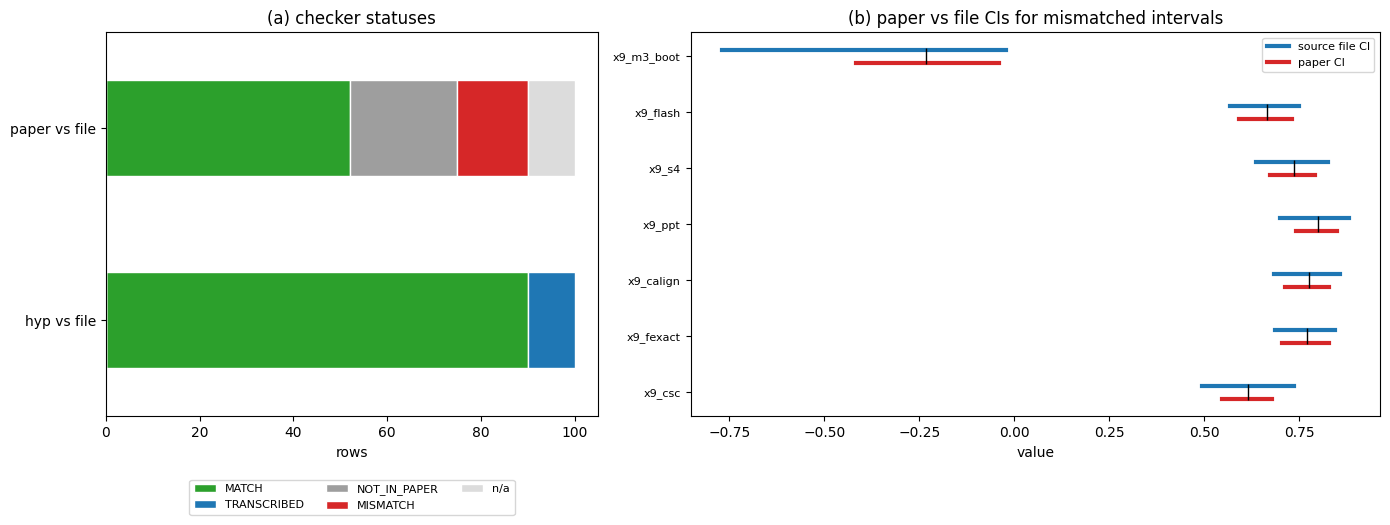

In [14]:
df = pd.DataFrame(ctx.rows)
print("hyp-vs-file :", dict(Counter(df.match_hyp_vs_file)))
print("paper-vs-file:", dict(Counter(df.match_paper_vs_file)))
print("review critique literals:", dict(Counter(r["status"] for r in rn)))

mm = df[df.match_paper_vs_file == "MISMATCH"][["id", "text", "value", "ci", "source_value", "source_ci", "paper_value", "paper_line"]]
pd.set_option("display.max_colwidth", 60, "display.width", 200)
print(f"\nPaper-vs-file MISMATCH rows ({len(mm)}):")
print(mm.to_string(index=False) if len(mm) else "  (none among the checked rows; raise N_CLAIMS)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), gridspec_kw={"width_ratios": [1, 1.4]})
# (a) status counts per direction
st = pd.DataFrame({"hyp vs file": Counter(df.match_hyp_vs_file), "paper vs file": Counter(df.match_paper_vs_file)}).fillna(0)
pal = {"MATCH": "#2ca02c", "MISMATCH": "#d62728", "TRANSCRIBED": "#1f77b4", "NOT_IN_PAPER": "#9e9e9e", "n/a": "#dcdcdc",
       "NOT_FOUND": "#ff7f0e", "AMBIGUOUS": "#9467bd"}
st.T.plot.barh(stacked=True, ax=axes[0], color=[pal.get(k, "#555555") for k in st.index], edgecolor="white")
axes[0].set_xlabel("rows"); axes[0].set_title("(a) checker statuses")
axes[0].legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
# (b) paper CI vs file CI for the mismatched intervals
ci_rows = [r for r in ctx.rows if r["match_paper_vs_file"] == "MISMATCH" and str(r.get("paper_value", "")).startswith("[") and r.get("source_ci_raw")]
ax = axes[1]
for k, r in enumerate(ci_rows):
    plo, phi = [CK.parse_literal(b)[0] for b in CK.parse_ci(r["paper_value"])]
    flo, fhi = r["source_ci_raw"]
    ax.plot([flo, fhi], [k + 0.12] * 2, color="#1f77b4", lw=3, label="source file CI" if k == 0 else None)
    ax.plot([plo, phi], [k - 0.12] * 2, color="#d62728", lw=3, label="paper CI" if k == 0 else None)
    if isinstance(r["source_value_raw"], float):
        ax.plot(r["source_value_raw"], k, "k|", ms=12)
ax.set_yticks(range(len(ci_rows))); ax.set_yticklabels([r["id"] for r in ci_rows], fontsize=8)
ax.set_title("(b) paper vs file CIs for mismatched intervals"); ax.set_xlabel("value")
if ci_rows: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()